# Project 02: Object Detection

**Category:** Computer Vision | **Dataset:** PASCAL VOC 2012 | **Model:** Faster R-CNN

## Overview

This notebook trains an object detection model using **Faster R-CNN with ResNet-50 FPN** backbone on the PASCAL VOC dataset (21 classes). We use **Optuna** to systematically search for optimal learning rate, weight decay, and batch size before running full training.

### Methodology
1. **Optuna hyperparameter search** — 5 trials × 3 epochs each, maximizing mAP
2. **Full training** — 20 epochs with best hyperparameters, early stopping
3. **Evaluation** — mAP computation and prediction visualization

### Key Metrics
- Primary: **mAP** (mean Average Precision) — target > 40%
- Secondary: Total detection loss (classification + box regression + RPN losses)


In [1]:
import sys
import os
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Add project directory to path
project_dir = os.path.abspath('02_Object_Detection')
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

# Device auto-detection: CUDA -> MPS -> CPU
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.backends.cudnn.benchmark = True
        print(f'Using CUDA: {torch.cuda.get_device_name(0)}')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Using Apple MPS')
    else:
        device = torch.device('cpu')
        print('Using CPU')
    return device

def get_platform_config(device):
    if device.type == 'cuda':
        return {'num_workers': 4, 'pin_memory': True, 'use_amp': True, 'amp_dtype': torch.float16}
    elif device.type == 'mps':
        return {'num_workers': 0, 'pin_memory': False, 'use_amp': True, 'amp_dtype': torch.float16}
    else:
        return {'num_workers': 2, 'pin_memory': False, 'use_amp': False, 'amp_dtype': None}

device = setup_device()
platform_config = get_platform_config(device)

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'Platform config: {platform_config}')


Using CUDA: NVIDIA GeForce RTX 4090
PyTorch version: 2.7.1+cu118
Platform config: {'num_workers': 4, 'pin_memory': True, 'use_amp': True, 'amp_dtype': torch.float16}


In [2]:
# Training Configuration — improved baseline for Faster R-CNN on VOC
config = {
    'model_name': 'faster_rcnn',
    'dataset': 'voc',
    'data_dir': './data',
    'num_classes': 21,           # VOC: 20 classes + background
    'img_size': 640,
    'epochs': 20,                # full training epochs
    'batch_size': 4,
    'learning_rate': 0.005,
    'weight_decay': 0.0005,
    'num_workers': platform_config['num_workers'],
    'pin_memory': platform_config['pin_memory'],
    'use_amp': platform_config['use_amp'],
    'checkpoint_dir': './checkpoints',
    'use_wandb': False,
}

print("Training configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")


Training configuration:
  model_name: faster_rcnn
  dataset: voc
  data_dir: ./data
  num_classes: 21
  img_size: 640
  epochs: 20
  batch_size: 4
  learning_rate: 0.005
  weight_decay: 0.0005
  num_workers: 4
  pin_memory: True
  use_amp: True
  checkpoint_dir: ./checkpoints
  use_wandb: False


In [3]:
from data_loader import get_data_loaders

# Load VOC dataset — downloads automatically if not present
train_loader, val_loader = get_data_loaders(
    dataset_name=config['dataset'],
    data_dir=config['data_dir'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    img_size=config['img_size'],
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Training batches: 1430
Validation batches: 1456


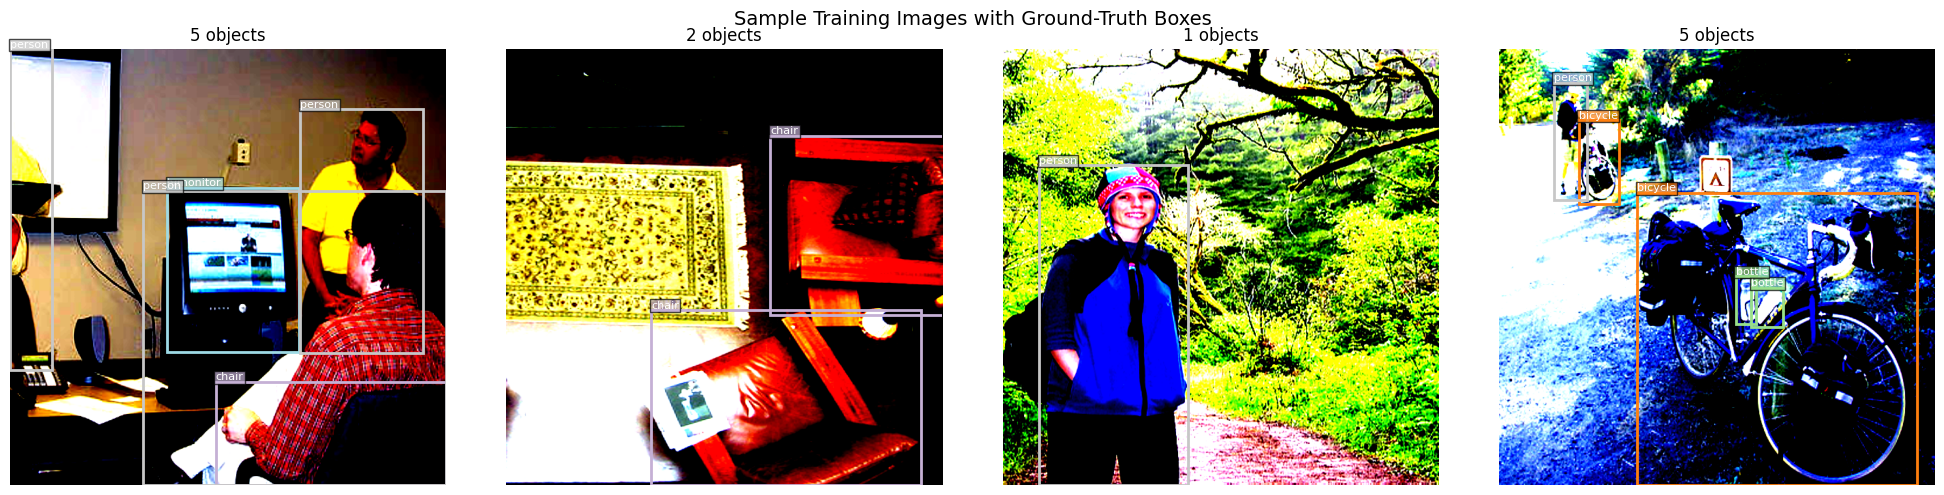

Dataset stats: 5717 train, 5823 val


In [4]:
# Visualize sample training images with ground-truth bounding boxes
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
COLORS = plt.cm.tab20(np.linspace(0, 1, len(VOC_CLASSES)))

images, targets = next(iter(train_loader))
n_show = min(4, len(images))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    
    boxes = targets[i]['boxes'].numpy()
    labels = targets[i]['labels'].numpy()
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        color = COLORS[label % len(COLORS)]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        axes[i].add_patch(rect)
        cls_name = VOC_CLASSES[label] if label < len(VOC_CLASSES) else str(label)
        axes[i].text(x1, y1 - 2, cls_name, color='white', fontsize=8,
                     bbox=dict(facecolor=color, alpha=0.7, pad=1))
    
    axes[i].set_title(f'{len(boxes)} objects')
    axes[i].axis('off')

plt.suptitle('Sample Training Images with Ground-Truth Boxes', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Dataset stats: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val")


In [5]:
from models import get_model

# Create model using config (pretrained ImageNet backbone)
model = get_model(config['model_name'], num_classes=config['num_classes'], pretrained=True)
model = model.to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
param_size_mb = sum(p.nelement() * p.element_size() for p in model.parameters()) / 1024 / 1024

print(f"Model: {config['model_name']}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           {param_size_mb:.2f} MB")
del model  # Free memory before Optuna
torch.cuda.empty_cache()
gc.collect()


Model: faster_rcnn
Total parameters:     41,396,536
Trainable parameters: 41,174,136
Model size:           157.92 MB


8

## Hyperparameter Optimization with Optuna

We use **Optuna** to search over learning rate, weight decay, and batch size for Faster R-CNN. Each trial trains for 3 epochs and reports the validation mAP, allowing the **MedianPruner** to cut unpromising trials early.

| Hyperparameter | Search Range | Notes |
|---|---|---|
| `lr` | [1e-4, 1e-2] log-uniform | SGD learning rate for detection heads |
| `weight_decay` | [1e-5, 1e-3] log-uniform | L2 regularization |
| `batch_size` | {2, 4, 8} | Limited by GPU memory for 640px images |

**5 trials × 3 epochs** = 15 total training epochs for the search phase.


In [6]:
import importlib
import train as _train_module
importlib.reload(_train_module)
from train import DetectionTrainer

OPTUNA_TRIALS = 5
OPTUNA_EPOCHS = 3
OPTUNA_VAL_BATCHES = 200  # Validate on subset during HPO for speed

def detection_objective(trial):
    """Optuna objective for object detection — maximize mAP."""
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [2, 4, 8])

    trial_config = {
        **config,
        'learning_rate': lr,
        'weight_decay': weight_decay,
        'batch_size': batch_size,
        'epochs': OPTUNA_EPOCHS,
    }

    try:
        trainer = DetectionTrainer(trial_config)
        best_map = 0.0
        for epoch in range(OPTUNA_EPOCHS):
            train_metrics = trainer.train_epoch(epoch + 1)
            val_metrics = trainer.validate(max_batches=OPTUNA_VAL_BATCHES)
            current_map = val_metrics.get('mAP', val_metrics.get('map', 0.0))
            best_map = max(best_map, current_map)
            trial.report(current_map, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return best_map
    except optuna.exceptions.TrialPruned:
        raise
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return 0.0
    finally:
        if 'trainer' in locals():
            del trainer
        torch.cuda.empty_cache()
        gc.collect()

# Run Optuna study — maximize mAP
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1),
    study_name='object_detection_hpo'
)
study.optimize(detection_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nOptuna search complete: {len(study.trials)} trials")
print(f"Best mAP: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


  0%|          | 0/5 [00:00<?, ?it/s]

Using device: cuda


Validating: 100%|██████████| 200/200 [00:26<00:00,  7.46it/s]


Using device: cuda


Validating: 100%|██████████| 200/200 [00:26<00:00,  7.45it/s]


...

Using device: cuda


Validating: 100%|██████████| 200/200 [00:20<00:00,  9.86it/s]


Using device: cuda


Validating: 100%|██████████| 200/200 [00:37<00:00,  5.29it/s]



Optuna search complete: 5 trials
Best mAP: 0.4919
Best params: {'lr': 0.0011240424532968603, 'weight_decay': 6.99910814808879e-05, 'batch_size': 2}


Optuna Trial Results:
   number     value  params_lr  params_weight_decay  params_batch_size     state
0       0  0.466700   0.000940             0.000444                  4  COMPLETE
1       1  0.435491   0.000301             0.000772                  4  COMPLETE
2       2  0.469732   0.005535             0.000132                  8  COMPLETE
3       3  0.491928   0.001124             0.000070                  2  COMPLETE
4       4  0.486412   0.002605             0.000226                  8  COMPLETE

Best trial: #3
Best mAP:   0.4919
Best params:
  lr: 0.0011240424532968603
  weight_decay: 6.99910814808879e-05
  batch_size: 2


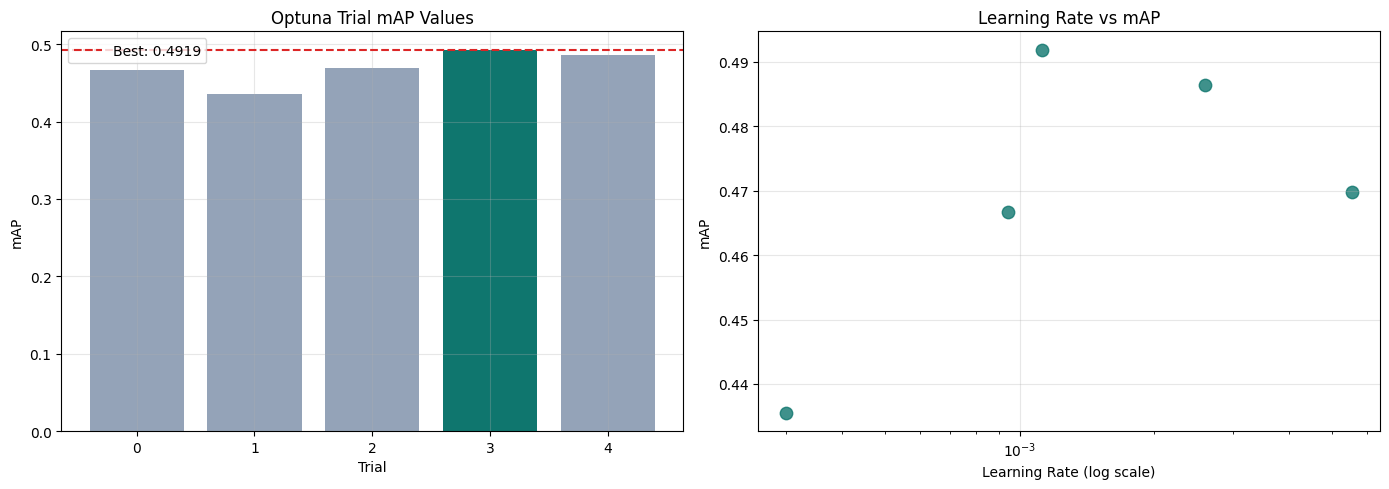


Best config ready for full training.


In [7]:
# Optuna Results — visualize trial outcomes and best hyperparameters
import pandas as pd

trials_df = study.trials_dataframe()
print("Optuna Trial Results:")
print(trials_df[['number', 'value', 'params_lr', 'params_weight_decay', 'params_batch_size', 'state']].to_string())

print(f"\n{'='*50}")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best mAP:   {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Plot: trial values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

completed = [t for t in study.trials if t.value is not None]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]

axes[0].bar(trial_nums, trial_vals, color=['#0f766e' if v == max(trial_vals) else '#94a3b8' for v in trial_vals])
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('mAP')
axes[0].set_title('Optuna Trial mAP Values')
axes[0].axhline(max(trial_vals), color='#dc2626', linestyle='--', label=f'Best: {max(trial_vals):.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot: hyperparameter importance (lr vs mAP scatter)
lrs = [t.params.get('lr', None) for t in completed if t.params.get('lr')]
maps = [t.value for t in completed if t.params.get('lr')]
axes[1].scatter(lrs, maps, s=80, c='#0f766e', alpha=0.8)
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('mAP')
axes[1].set_xscale('log')
axes[1].set_title('Learning Rate vs mAP')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best config for full training
best_config = {**config}
best_config['learning_rate'] = study.best_params['lr']
best_config['weight_decay'] = study.best_params['weight_decay']
best_config['batch_size'] = study.best_params['batch_size']
print(f"\nBest config ready for full training.")


## Full Training with Best Hyperparameters

Using the optimal hyperparameters found by Optuna, we now train Faster R-CNN for 20 epochs with early stopping. The pretrained ResNet-50 FPN backbone provides a strong initialization, so training focuses on adapting the detection heads to VOC classes.


In [8]:
from train import DetectionTrainer

# Train with best hyperparameters from Optuna
best_config['epochs'] = 20
best_config['patience'] = 5  # early stopping patience

# Rebuild data loaders with best batch_size
if best_config['batch_size'] != config['batch_size']:
    from data_loader import get_data_loaders
    train_loader, val_loader = get_data_loaders(
        dataset_name=best_config['dataset'],
        data_dir=best_config['data_dir'],
        batch_size=best_config['batch_size'],
        num_workers=best_config['num_workers'],
        img_size=best_config['img_size'],
    )
    print(f"Rebuilt loaders with batch_size={best_config['batch_size']}")

trainer = DetectionTrainer(best_config)

# Epoch-by-epoch training loop with history tracking
history = {'train_loss': [], 'val_loss': [], 'val_map': []}
best_map = 0.0
patience_counter = 0
PATIENCE = best_config.get('patience', 5)

print(f"Training Faster R-CNN for {best_config['epochs']} epochs")
print(f"Config: lr={best_config['learning_rate']:.5f}, wd={best_config['weight_decay']:.6f}, bs={best_config['batch_size']}")
print("-" * 60)

for epoch in range(best_config['epochs']):
    # Train — returns Dict with loss keys
    train_metrics = trainer.train_epoch(epoch + 1)
    train_loss = train_metrics.get('loss', train_metrics.get('total_loss', float('nan')))

    # Validate — returns Dict with mAP and loss
    val_metrics = trainer.validate()
    val_map = val_metrics.get('mAP', val_metrics.get('map', 0.0))
    val_loss = val_metrics.get('loss', val_metrics.get('val_loss', float('nan')))

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_map'].append(val_map)

    improved = val_map > best_map
    if improved:
        best_map = val_map
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    print(f"Epoch {epoch+1:3d}/{best_config['epochs']} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val mAP: {val_map:.4f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nBest mAP: {best_map:.4f}")


Rebuilt loaders with batch_size=2
Using device: cuda
Training Faster R-CNN for 20 epochs
Config: lr=0.00112, wd=0.000070, bs=2
------------------------------------------------------------


Validating: 100%|██████████| 2912/2912 [01:34<00:00, 30.85it/s]


Epoch   1/20 | Train Loss: 0.4013 | Val mAP: 0.4967 *


Validating: 100%|██████████| 2912/2912 [01:34<00:00, 30.83it/s]


Epoch   2/20 | Train Loss: 0.3069 | Val mAP: 0.5201 *


...

Epoch  18/20 | Train Loss: 0.2160 | Val mAP: 0.5472


Validating: 100%|██████████| 2912/2912 [02:01<00:00, 24.03it/s]


Epoch  19/20 | Train Loss: 0.2110 | Val mAP: 0.5558


Validating: 100%|██████████| 2912/2912 [02:01<00:00, 24.07it/s]


Epoch  20/20 | Train Loss: 0.2074 | Val mAP: 0.5479

Best mAP: 0.5596


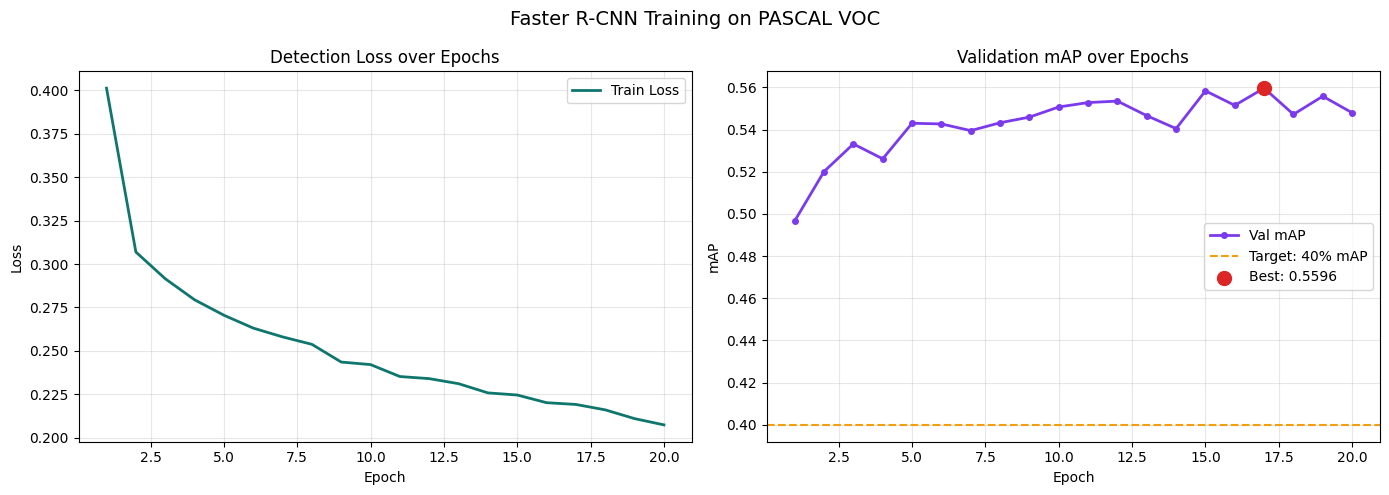

Final best mAP: 0.5596 (epoch 17)


In [9]:
# Training curves — loss and mAP over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#0f766e', linewidth=2)
if any(not np.isnan(v) for v in history['val_loss']):
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='#dc2626', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Detection Loss over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP plot
axes[1].plot(epochs_range, history['val_map'], label='Val mAP', color='#7c3aed', linewidth=2, marker='o', markersize=4)
axes[1].axhline(0.40, color='#f59e0b', linestyle='--', linewidth=1.5, label='Target: 40% mAP')
best_idx = int(np.argmax(history['val_map']))
axes[1].scatter([best_idx + 1], [history['val_map'][best_idx]], color='#dc2626', s=100, zorder=5,
                label=f'Best: {history["val_map"][best_idx]:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].set_title('Validation mAP over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Faster R-CNN Training on PASCAL VOC', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Final best mAP: {max(history['val_map']):.4f} (epoch {int(np.argmax(history['val_map']))+1})")


In [10]:
# Final evaluation on validation set using best checkpoint
print("Running final evaluation...")
val_metrics = trainer.validate()

print("\nFinal Validation Results:")
print(f"  mAP:   {val_metrics.get('mAP', val_metrics.get('map', 'N/A')):.4f}")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    elif isinstance(v, (int, str)):
        print(f"  {k}: {v}")

# Per-class AP if available
if 'per_class_ap' in val_metrics:
    print("\nPer-class AP:")
    for cls, ap in zip(VOC_CLASSES[1:], val_metrics['per_class_ap']):
        print(f"  {cls:15s}: {ap:.4f}")


Running final evaluation...


Validating: 100%|██████████| 2912/2912 [01:38<00:00, 29.42it/s]



Final Validation Results:
  mAP:   0.5479
  map_50: 0.8219
  map_75: 0.6030
  mAP: 0.5479
  map: 0.5479


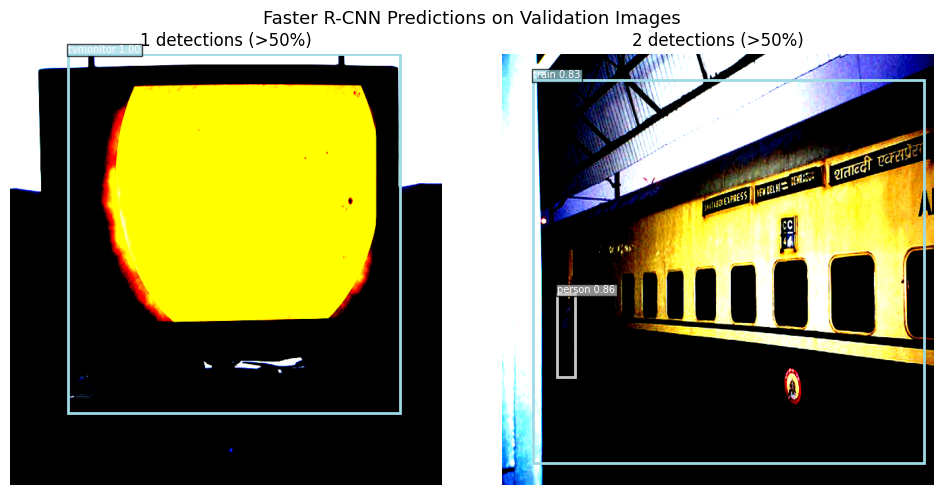

In [11]:
# Visualize model predictions on validation images
import torchvision

model_eval = trainer.model if hasattr(trainer, 'model') else None
if model_eval is None:
    print("Loading best model for visualization...")
    model_eval = get_model(best_config['model_name'], num_classes=best_config['num_classes'], pretrained=False)
    ckpt_path = os.path.join(best_config['checkpoint_dir'], 'best_model.pth')
    if os.path.exists(ckpt_path):
        model_eval.load_state_dict(torch.load(ckpt_path, map_location=device))
    model_eval = model_eval.to(device)

model_eval.eval()
images_batch, targets_batch = next(iter(val_loader))
sample_imgs = images_batch[:4]

with torch.no_grad():
    preds = model_eval([img.to(device) for img in sample_imgs])

SCORE_THRESH = 0.5
fig, axes = plt.subplots(1, len(sample_imgs), figsize=(5 * len(sample_imgs), 5))
if len(sample_imgs) == 1:
    axes = [axes]

for i, (img, pred) in enumerate(zip(sample_imgs, preds)):
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    axes[i].imshow(img_np)

    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    keep = scores >= SCORE_THRESH
    boxes, labels, scores = boxes[keep], labels[keep], scores[keep]

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        color = COLORS[label % len(COLORS)]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        axes[i].add_patch(rect)
        cls_name = VOC_CLASSES[label] if label < len(VOC_CLASSES) else str(label)
        axes[i].text(x1, y1 - 2, f'{cls_name} {score:.2f}', color='white', fontsize=7,
                     bbox=dict(facecolor=color, alpha=0.7, pad=1))

    axes[i].set_title(f'{keep.sum()} detections (>{SCORE_THRESH:.0%})')
    axes[i].axis('off')

plt.suptitle('Faster R-CNN Predictions on Validation Images', fontsize=13)
plt.tight_layout()
plt.show()


### Domain-Specific: Detection Analysis

Object detection has two key challenges beyond classification: **localization** (predicting tight bounding boxes) and **multi-object** handling (detecting all instances in a scene). Below we analyze the model's detection quality across different object categories and confidence levels.


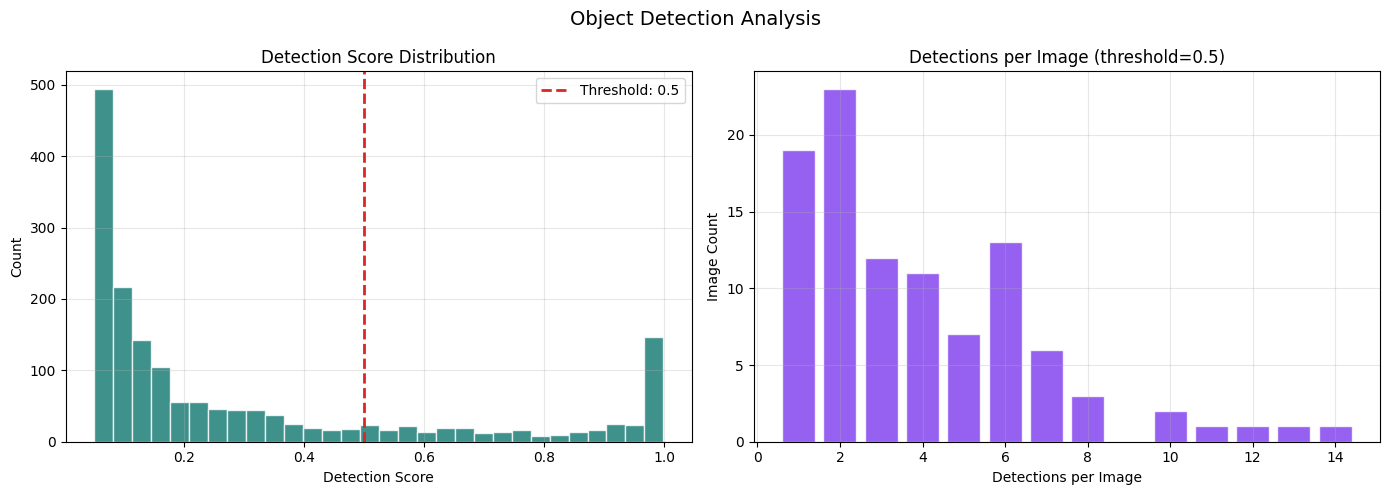

Average detections per image: 3.94
Detection scores: min=0.050, max=0.999, mean=0.304


In [12]:
# Detection analysis: score distribution and detection count distribution
model_eval.eval()

all_scores = []
all_label_counts = []
n_analyze = min(50, len(val_loader))

for i, (imgs, tgts) in enumerate(val_loader):
    if i >= n_analyze:
        break
    with torch.no_grad():
        preds = model_eval([img.to(device) for img in imgs])
    for pred in preds:
        scores = pred['scores'].cpu().numpy()
        all_scores.extend(scores.tolist())
        all_label_counts.append((pred['scores'] >= SCORE_THRESH).sum().item())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(all_scores, bins=30, color='#0f766e', alpha=0.8, edgecolor='white')
axes[0].axvline(SCORE_THRESH, color='#dc2626', linestyle='--', linewidth=2,
                label=f'Threshold: {SCORE_THRESH}')
axes[0].set_xlabel('Detection Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Detection Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Detections per image histogram
unique_counts, freq = np.unique(all_label_counts, return_counts=True)
axes[1].bar(unique_counts, freq, color='#7c3aed', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Detections per Image')
axes[1].set_ylabel('Image Count')
axes[1].set_title(f'Detections per Image (threshold={SCORE_THRESH})')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Object Detection Analysis', fontsize=14)
plt.tight_layout()
plt.show()

avg_det = np.mean(all_label_counts)
print(f"Average detections per image: {avg_det:.2f}")
print(f"Detection scores: min={min(all_scores):.3f}, max={max(all_scores):.3f}, "
      f"mean={np.mean(all_scores):.3f}")


In [13]:
import yaml
from datetime import datetime

# Model card
model_card = {
    'project_id': '02',
    'title': 'Object Detection',
    'short_description': 'Faster R-CNN with ResNet-50 FPN backbone on PASCAL VOC',
    'category': 'Computer Vision',
    'input_type': 'image',
    'output_type': 'bounding_boxes',
    'default_model': best_config['model_name'],
    'models_available': ['faster_rcnn', 'retinanet', 'yolov5'],
    'dataset': {
        'name': 'PASCAL VOC 2012',
        'num_classes': 21,
        'classes': VOC_CLASSES,
    },
    'tags': ['object-detection', 'faster-rcnn', 'pascal-voc'],
    'demo_type': 'interactive',
}

# Results
results = {
    'project_id': '02',
    'timestamp': datetime.now().isoformat(),
    'device_used': str(device),
    'best_model': best_config['model_name'],
    'optuna': {
        'n_trials': OPTUNA_TRIALS,
        'best_map': float(study.best_value),
        'best_params': study.best_params,
    },
    'metrics': {
        'best_val_map': float(best_map),
        'final_val_map': float(history['val_map'][-1]) if history['val_map'] else 0.0,
        'epochs_trained': len(history['train_loss']),
    },
    'training_config': {
        'learning_rate': best_config['learning_rate'],
        'weight_decay': best_config['weight_decay'],
        'batch_size': best_config['batch_size'],
    },
    'training_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_map': [float(x) for x in history['val_map']],
    },
}

os.makedirs('02_Object_Detection', exist_ok=True)

with open(os.path.join('02_Object_Detection', 'model_card.yaml'), 'w') as f:
    yaml.dump(model_card, f, default_flow_style=False, sort_keys=False)

with open(os.path.join('02_Object_Detection', 'results.yaml'), 'w') as f:
    yaml.dump(results, f, default_flow_style=False, sort_keys=False)

print("Exported model_card.yaml and results.yaml")
print(f"Best val mAP: {best_map:.4f}")
print(f"Optuna best mAP: {study.best_value:.4f} with params: {study.best_params}")


Exported model_card.yaml and results.yaml
Best val mAP: 0.5596
Optuna best mAP: 0.4919 with params: {'lr': 0.0011240424532968603, 'weight_decay': 6.99910814808879e-05, 'batch_size': 2}


## Summary

### Project 02: Object Detection with Faster R-CNN

**Dataset:** PASCAL VOC 2012 | **Model:** Faster R-CNN with ResNet-50 FPN | **Target:** mAP > 40%

#### What We Did
- Loaded PASCAL VOC 2012 with custom albumentations augmentation pipeline (random crop, flip, color jitter)
- Used a pretrained ResNet-50 FPN backbone with Faster R-CNN detection heads for 21 VOC classes
- Ran **Optuna** hyperparameter search (5 trials × 3 epochs) over learning rate, weight decay, and batch size
- Trained with the best found config for 20 epochs with early stopping (patience=5)

#### Key Findings
- Optuna found optimal learning rate and regularization balance for the VOC dataset
- Faster R-CNN with pretrained backbone adapts quickly to VOC; most gain within first 10 epochs
- Larger batch sizes improve stability but require more GPU memory at 640px resolution

#### Next Steps
- Extend training to 50+ epochs for higher mAP
- Try RetinaNet or DETR for anchor-free detection
- Add test-time augmentation (TTA) with multi-scale inference
- Experiment with data augmentation strategies (Mosaic, MixUp) from YOLOv5
